# ADRD User Evaluation Survey Analysis

This notebook cleans the user evaluation survey, standardizes participant roles, filters the sample according to the thesis inclusion logic, and analyzes user acceptance and usability using the following dimensions:

- **Performance Expectancy (PE)**
- **Effort Expectancy (EE)**
- **Behavioural Intention (BI)**
- **Technology Anxiety (TA)**
- **Perceived Trust (PT)** *(inferred from trust- and concern-related items)*
- **Expert Advice (EA)**

## Cleaning and inclusion rules
Responses are filtered as follows:
- Keep respondents who answered **Yes** to having interacted with an ADRD patient.
- Also keep respondents who answered **No** **only if** their standardized role is:
  - Physician
  - Nurse
  - Allied Medical Professional

## Role standardization
Overlapping role labels are grouped into cleaner categories:
- `Retired nurse` -> `Nurse`
- `Other Allied Medical Professionals` -> `Allied Medical Professional`
- `Family caregiver / Patient Relative`, `Family caregiver`, and `Patient relative` -> `Patient Relative`

## Statistical approach
For each dimension, the notebook reports:
- descriptive statistics
- reliability (Cronbach's alpha, where applicable)
- one-sample **t-tests vs the neutral midpoint = 3**
- **Wilcoxon signed-rank tests** vs the neutral midpoint for robustness
- 95% confidence intervals
- Cohen's *d*
- role-based comparisons using **Kruskal-Wallis**

This structure is designed to support the thesis write-up by showing whether user acceptance and usability are statistically above neutral.


In [12]:

import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

CSV_PATH = Path(r"/Users/alexandrakhreiche/Desktop/Capstone_Code/tests/AI Home Support System for ADRD Care – User Evaluation Survey  (Responses) - Form responses 1.csv")
OUTPUT_DIR = Path("/Users/alexandrakhreiche/Desktop/Capstone_Code/tests/adrd_survey_analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (24, 35)


,Timestamp,Q1. What is your role?,Q2. Have you interacted with a patient with Alzheimer's Disease?,Q3. What is your age group?,Q4. The system interface is visually clear and easy to understand,Q5. The avatar feels natural and comforting,Q6. The design is appropriate for elderly users,Q7. The system feels easy to interact with,Q8. The system feels engaging,Q9. First impression of the system,Q10. The system would help improve patient safety,Q11. The reminder system is useful for daily routines,Q12. The emotional interaction (avatar) is valuable,Q13. The system reduces caregiver burden,Q14. The system responds appropriately to situations,Q15. Which feature did you find most useful?,Q16. Which feature needs improvement?,Q17. I am concerned about the system making incorrect decisions,Q18. I am concerned about over-reliance on the system,Q19. I am concerned about privacy and data security,Q20. I believe the system could cause emotional discomfort,Q21. What risks or concerns do you see in this system?,Q22. I would consider using this system,Q23. I would recommend this system to others,Q24. I believe this system adds value to ADRD care,Q25. How likely are you to recommend this system?,Q26. I feel nervous when using AI-based systems like this,Q27. I find systems like this intimidating,Q28. I feel uncomfortable relying on this technology,Q29. I would need assistance to use this system,Q30. I would trust this system more if recommended by a doctor,Q31. I would trust this system more if it was designed alongside a medical professional,Q32. What would you improve in this system?,Q33. Are there any features not represented that you believe would add additional value to the system?,Q34. Any additional comments?
0,19/03/2026 10:40:39,Family caregiver,Yes,18-25,4,3,4,4,5,"My first impression of the system, is that it ...",4,5,4,4,4,Safety and Reminder tools,"Avatar image, would like something that flows ...",3,2,2,1,The main risk I see is that the patient just w...,4,4,5,5,1,3,2,2,4,4,I think everything works very good but the ava...,"nope, you have every feature, you could add me...",nope :)
1,19/03/2026 11:45:54,Family caregiver,Yes,18-25,5,5,5,5,5,This is very well thought out. This is especia...,5,5,5,5,5,The insight tool,Unfortunately I have no improvement comments. ...,1,4,2,2,I don’t not see risks.,5,5,5,5,2,2,2,4,4,4,No improvement comments,All areas were covered,NaN
2,19/03/2026 11:48:36,Family caregiver,No,55+,5,5,5,4,5,Helpful,5,5,5,4,4,Avatar personal\n,Speed of response,3,2,1,2,NaN,5,5,5,5,1,1,2,2,2,3,Multi cameras,Family members resemblence,NaN
3,19/03/2026 11:54:18,Professional caregiver,Yes,36-55,5,5,5,4,5,"Great innovation, the lady is very real",5,4,5,5,4,The lady who speaks,Nothing in mind,2,2,2,2,i dont really know how technology works to kno...,5,5,5,5,2,2,2,2,5,5,nothing i could think of,Noi,No
4,19/03/2026 12:19:37,Patient relative,Yes,36-55,5,4,5,5,5,"I think everything about it is great, but perh...",5,5,5,5,5,The avatars ability to deal with the patients ...,The speech quality of the avatar.,3,2,1,2,The patient maybe being scared of the avatar. ...,5,5,5,5,1,1,1,1,4,2,"Firstly, I think the speech quality of the ava...",I believe I mentioned this in my answer above.,"I think this is a wonderful initiative, and I ..."


In [13]:

ROLE_COL = "Q1. What is your role?"
ADRD_COL = "Q2. Have you interacted with a patient with Alzheimer's Disease? "

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x

def standardize_role(role):
    r = normalize_text(role)
    if pd.isna(r):
        return np.nan

    if any(k in r for k in ["physician", "doctor", "medical doctor", "gp"]):
        return "Physician"

    if "nurse" in r:
        return "Nurse"

    if any(k in r for k in [
        "other allied medical professional",
        "allied medical",
        "allied health",
        "occupational therapist",
        "psychologist",
        "clinical psychologist",
        "therapist",
        "speech therapist",
        "physiotherapist",
        "social worker"
    ]):
        return "Allied Medical Professional"

    if any(k in r for k in [
        "professional caregiver",
        "elderly care professional",
        "formal caregiver",
        "paid caregiver",
        "care assistant"
    ]):
        return "Professional Caregiver"

    if any(k in r for k in [
        "family caregiver / patient relative",
        "family caregiver",
        "patient relative",
        "relative"
    ]):
        return "Patient Relative"

    return str(role).strip()

df = df_raw.copy()
df["role_standardized"] = df[ROLE_COL].apply(standardize_role)

role_map_table = (
    df[[ROLE_COL, "role_standardized"]]
    .drop_duplicates()
    .sort_values(["role_standardized", ROLE_COL])
    .reset_index(drop=True)
)
role_map_table


,Q1. What is your role?,role_standardized
0,Other Allied Medical Professionals,Allied Medical Professional
1,Nurse,Nurse
2,Retired nurse,Nurse
3,Family caregiver,Patient Relative
4,Family caregiver / Patient Relative,Patient Relative
5,Patient relative,Patient Relative
6,Physician,Physician
7,Professional caregiver,Professional Caregiver


In [14]:

allowed_no_interaction_roles = {
    "Physician",
    "Nurse",
    "Allied Medical Professional",
}

def interacted_yes(x):
    return normalize_text(x) == "yes"

df["include_response"] = (
    df[ADRD_COL].apply(interacted_yes)
    | df["role_standardized"].isin(allowed_no_interaction_roles)
)

df_clean = df[df["include_response"]].copy()

print("Original sample size:", len(df))
print("Filtered sample size:", len(df_clean))
print("\nRole counts after cleaning:")
display(df_clean["role_standardized"].value_counts().rename_axis("role").reset_index(name="count"))


Original sample size: 24
Filtered sample size: 22

Role counts after cleaning:


,role,count
0,Patient Relative,8
1,Physician,5
2,Professional Caregiver,4
3,Allied Medical Professional,3
4,Nurse,2


In [15]:

# Convert Likert items to numeric
likert_cols = [c for c in df_clean.columns if re.match(r"Q\d+\.", str(c)) and c not in [
    "Q1. What is your role?",
    "Q2. Have you interacted with a patient with Alzheimer's Disease? ",
    "Q3. What is your age group?",
    "Q9. First impression of the system",
    "Q15. Which feature did you find most useful?",
    "Q16. Which feature needs improvement?",
    "Q21. What risks or concerns do you see in this system? ",
    "Q32. What would you improve in this system?",
    "Q33. Are there any features not represented that you believe would add additional value to the system?",
    "Q34. Any additional comments?"
]]

for col in likert_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Define construct items
construct_items = {
    "EE": [
        "Q4. The system interface is visually clear and easy to understand",
        "Q5. The avatar feels natural and comforting",
        "Q6. The design is appropriate for elderly users",
        "Q7. The system feels easy to interact with",
        "Q8. The system feels engaging",
    ],
    "PE": [
        "Q10. The system would help improve patient safety",
        "Q11. The reminder system is useful for daily routines",
        "Q12. The emotional interaction (avatar) is valuable",
        "Q13. The system reduces caregiver burden",
        "Q14. The system responds appropriately to situations",
    ],
    "BI": [
        "Q22. I would consider using this system",
        "Q23. I would recommend this system to others",
        "Q24. I believe this system adds value to ADRD care",
        "Q25. How likely are you to recommend this system?",
    ],
    "TA": [
        "Q26. I feel nervous when using AI-based systems like this",
        "Q27. I find systems like this intimidating",
        "Q28. I feel uncomfortable relying on this technology",
        "Q29. I would need assistance to use this system",
    ],
    "EA": [
        "Q30. I would trust this system more if recommended by a doctor",
        "Q31. I would trust this system more if it was designed alongside a medical professional ",
    ],
}

# Perceived Trust is inferred from confidence and concern-related items.
# Reverse-code concern items so higher values consistently indicate higher trust.
trust_direct = ["Q14. The system responds appropriately to situations"]
trust_reverse = [
    "Q17. I am concerned about the system making incorrect decisions",
    "Q18. I am concerned about over-reliance on the system",
    "Q19. I am concerned about privacy and data security",
    "Q20. I believe the system could cause emotional discomfort",
]

for col in trust_reverse:
    df_clean[f"{col} [reversed]"] = 6 - df_clean[col]

construct_items["PT"] = trust_direct + [f"{c} [reversed]" for c in trust_reverse]

# Create construct scores
for construct, cols in construct_items.items():
    df_clean[construct] = df_clean[cols].mean(axis=1)

construct_items


{'EE': ['Q4. The system interface is visually clear and easy to understand',
  'Q5. The avatar feels natural and comforting',
  'Q6. The design is appropriate for elderly users',
  'Q7. The system feels easy to interact with',
  'Q8. The system feels engaging'],
 'PE': ['Q10. The system would help improve patient safety',
  'Q11. The reminder system is useful for daily routines',
  'Q12. The emotional interaction (avatar) is valuable',
  'Q13. The system reduces caregiver burden',
  'Q14. The system responds appropriately to situations'],
 'BI': ['Q22. I would consider using this system',
  'Q23. I would recommend this system to others',
  'Q24. I believe this system adds value to ADRD care',
  'Q25. How likely are you to recommend this system?'],
 'TA': ['Q26. I feel nervous when using AI-based systems like this',
  'Q27. I find systems like this intimidating',
  'Q28. I feel uncomfortable relying on this technology',
  'Q29. I would need assistance to use this system'],
 'EA': ['Q30.

In [28]:

# Save cleaned dataset
df_clean.to_csv(OUTPUT_DIR / "cleaned_survey_data.csv", index=False)

display(df_clean[["role_standardized", "EE", "PE", "BI", "TA", "PT", "EA"]].head())


,role_standardized,EE,PE,BI,TA,PT,EA
0,Patient Relative,4.0,4.2,4.5,2.00,4.0,4.0
1,Patient Relative,5.0,5.0,5.0,2.50,4.0,4.0
3,Professional Caregiver,4.8,4.6,5.0,2.00,4.0,5.0
4,Patient Relative,4.8,5.0,5.0,1.00,4.2,3.0
5,Patient Relative,5.0,4.4,5.0,1.75,4.6,3.0


In [17]:

def cronbach_alpha(items_df):
    items_df = items_df.dropna()
    if items_df.shape[1] < 2 or len(items_df) < 2:
        return np.nan
    item_vars = items_df.var(ddof=1, axis=0)
    total_score = items_df.sum(axis=1)
    total_var = total_score.var(ddof=1)
    k = items_df.shape[1]
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

reliability_rows = []
for construct, cols in construct_items.items():
    alpha = cronbach_alpha(df_clean[cols])
    reliability_rows.append({
        "Construct": construct,
        "Items": len(cols),
        "Cronbach_alpha": round(alpha, 3) if pd.notna(alpha) else np.nan
    })

reliability_df = pd.DataFrame(reliability_rows).sort_values("Construct")
reliability_df.to_csv(OUTPUT_DIR / "reliability_summary.csv", index=False)
reliability_df


,Construct,Items,Cronbach_alpha
2,BI,4,0.949
4,EA,2,0.836
0,EE,5,0.792
1,PE,5,0.745
5,PT,5,0.740
3,TA,4,0.716


In [30]:

# Descriptive summary
construct_labels = {
    "PE": "Performance Expectancy",
    "EE": "Effort Expectancy",
    "BI": "Behavioural Intention",
    "TA": "Technology Anxiety",
    "PT": "Perceived Trust",
    "EA": "Expert Advice",
}

desc_rows = []
for construct in ["PE", "EE", "BI", "TA", "PT", "EA"]:
    scores = df_clean[construct].dropna()
    desc_rows.append({
        "Construct": construct,
        "Label": construct_labels[construct],
        "Mean": round(scores.mean(), 3),
        "Median": round(scores.median(), 3),
        "SD": round(scores.std(ddof=1), 3),
        "Min": round(scores.min(), 3),
        "Max": round(scores.max(), 3),
    })

descriptive_df = pd.DataFrame(desc_rows)
descriptive_df.to_csv(OUTPUT_DIR / "construct_descriptives.csv", index=False)
descriptive_df


,Construct,Label,Mean,Median,SD,Min,Max
0,PE,Performance Expectancy,4.455,4.400,0.450,3.40,5.0
1,EE,Effort Expectancy,4.300,4.200,0.500,3.40,5.0
2,BI,Behavioural Intention,4.261,4.375,0.717,2.75,5.0
3,TA,Technology Anxiety,2.489,2.375,0.692,1.00,4.0
4,PT,Perceived Trust,3.527,3.500,0.719,2.20,4.8
5,EA,Expert Advice,4.068,4.000,0.955,2.00,5.0


In [19]:

# Statistical tests against neutral midpoint = 3
NEUTRAL = 3

def wilcoxon_against_midpoint(series, midpoint=3):
    diffs = series.dropna() - midpoint
    diffs = diffs[diffs != 0]
    if len(diffs) == 0:
        return np.nan, np.nan
    stat, p = stats.wilcoxon(diffs)
    return stat, p

test_rows = []

for construct in ["PE", "EE", "BI", "TA", "PT", "EA"]:
    s = df_clean[construct].dropna()
    n = len(s)
    mean_val = s.mean()
    sd_val = s.std(ddof=1)
    sem = sd_val / np.sqrt(n) if n > 1 else np.nan
    ci_low, ci_high = stats.t.interval(
        0.95, df=n-1, loc=mean_val, scale=sem
    ) if n > 1 else (np.nan, np.nan)

    t_stat, t_p = stats.ttest_1samp(s, popmean=NEUTRAL, nan_policy="omit") if n > 1 else (np.nan, np.nan)
    w_stat, w_p = wilcoxon_against_midpoint(s, midpoint=NEUTRAL)

    cohen_d = (mean_val - NEUTRAL) / sd_val if (pd.notna(sd_val) and sd_val != 0) else np.nan

    test_rows.append({
        "Construct": construct,
        "Label": construct_labels[construct],
        "N": n,
        "Mean": round(mean_val, 3),
        "Test_midpoint": NEUTRAL,
        "95% CI low": round(ci_low, 3) if pd.notna(ci_low) else np.nan,
        "95% CI high": round(ci_high, 3) if pd.notna(ci_high) else np.nan,
        "t_stat": round(t_stat, 3) if pd.notna(t_stat) else np.nan,
        "t_p_value": round(t_p, 4) if pd.notna(t_p) else np.nan,
        "Wilcoxon_stat": round(w_stat, 3) if pd.notna(w_stat) else np.nan,
        "Wilcoxon_p_value": round(w_p, 4) if pd.notna(w_p) else np.nan,
        "Cohen_d": round(cohen_d, 3) if pd.notna(cohen_d) else np.nan,
        "Direction_vs_neutral": "Above neutral" if mean_val > NEUTRAL else ("Below neutral" if mean_val < NEUTRAL else "Equal to neutral"),
        "Significant_t_0.05": bool(t_p < 0.05) if pd.notna(t_p) else np.nan,
        "Significant_wilcoxon_0.05": bool(w_p < 0.05) if pd.notna(w_p) else np.nan,
    })

tests_df = pd.DataFrame(test_rows)
tests_df.to_csv(OUTPUT_DIR / "construct_significance_tests.csv", index=False)
tests_df


,Construct,Label,N,Mean,Test_midpoint,95% CI low,95% CI high,t_stat,t_p_value,Wilcoxon_stat,Wilcoxon_p_value,Cohen_d,Direction_vs_neutral,Significant_t_0.05,Significant_wilcoxon_0.05
0,PE,Performance Expectancy,22,4.455,3,4.255,4.654,15.157,0.0000,0.0,0.0000,3.232,Above neutral,True,True
1,EE,Effort Expectancy,22,4.300,3,4.078,4.522,12.183,0.0000,0.0,0.0000,2.598,Above neutral,True,True
2,BI,Behavioural Intention,22,4.261,3,3.943,4.579,8.246,0.0000,1.5,0.0001,1.758,Above neutral,True,True
3,TA,Technology Anxiety,22,2.489,3,2.182,2.796,-3.465,0.0023,20.5,0.0044,-0.739,Below neutral,True,True
4,PT,Perceived Trust,22,3.527,3,3.209,3.846,3.442,0.0024,32.5,0.0037,0.734,Above neutral,True,True
5,EA,Expert Advice,22,4.068,3,3.645,4.492,5.247,0.0000,11.0,0.0004,1.119,Above neutral,True,True


In [21]:

# Role-based comparisons
role_counts = df_clean["role_standardized"].value_counts()
eligible_roles = role_counts[role_counts >= 2].index.tolist()

role_test_df = df_clean[df_clean["role_standardized"].isin(eligible_roles)].copy()

kruskal_rows = []
for construct in ["PE", "EE", "BI", "TA", "PT", "EA"]:
    grouped = []
    role_names = []
    for role, sub in role_test_df.groupby("role_standardized"):
        vals = sub[construct].dropna()
        if len(vals) >= 2:
            grouped.append(vals)
            role_names.append(role)

    if len(grouped) >= 2:
        h_stat, p_val = stats.kruskal(*grouped)
    else:
        h_stat, p_val = np.nan, np.nan

    kruskal_rows.append({
        "Construct": construct,
        "Label": construct_labels[construct],
        "Included_roles": ", ".join(role_names),
        "Kruskal_H": round(h_stat, 3) if pd.notna(h_stat) else np.nan,
        "p_value": round(p_val, 4) if pd.notna(p_val) else np.nan,
        "Significant_role_difference_0.05": bool(p_val < 0.05) if pd.notna(p_val) else np.nan
    })

kruskal_df = pd.DataFrame(kruskal_rows)
kruskal_df.to_csv(OUTPUT_DIR / "role_difference_tests.csv", index=False)
kruskal_df


,Construct,Label,Included_roles,Kruskal_H,p_value,Significant_role_difference_0.05
0,PE,Performance Expectancy,"Allied Medical Professional, Nurse, Patient Re...",3.863,0.4248,False
1,EE,Effort Expectancy,"Allied Medical Professional, Nurse, Patient Re...",5.448,0.2444,False
2,BI,Behavioural Intention,"Allied Medical Professional, Nurse, Patient Re...",9.612,0.0475,True
3,TA,Technology Anxiety,"Allied Medical Professional, Nurse, Patient Re...",7.748,0.1013,False
4,PT,Perceived Trust,"Allied Medical Professional, Nurse, Patient Re...",6.270,0.1798,False
5,EA,Expert Advice,"Allied Medical Professional, Nurse, Patient Re...",1.094,0.8951,False


In [22]:

# Means by standardized role
role_means = (
    df_clean.groupby("role_standardized")[["PE", "EE", "BI", "TA", "PT", "EA"]]
    .agg(["mean", "count"])
)

role_means.to_csv(OUTPUT_DIR / "role_means.csv")
role_means


PE              EE              BI             TA              PT           EA      
                                 mean count      mean count      mean count     mean count      mean count   mean count
role_standardized                                                                                                      
Allied Medical Professional  4.333333     3  4.133333     3  4.166667     3  2.00000     3  3.933333     3  4.500     3
Nurse                        4.400000     2  4.400000     2  3.875000     2  3.00000     2  3.400000     2  3.750     2
Patient Relative             4.600000     8  4.525000     8  4.687500     8  2.21875     8  3.850000     8  4.125     8
Physician                    4.120000     5  3.920000     5  3.500000     5  3.10000     5  2.960000     5  3.900     5
Professional Caregiver       4.700000     4  4.400000     4  4.625000     4  2.37500     4  3.350000     4  4.000     4

In [23]:

# Item-level summary
item_rows = []
for construct, cols in construct_items.items():
    for col in cols:
        item_rows.append({
            "Construct": construct,
            "Item": col,
            "Mean": round(df_clean[col].mean(), 3),
            "Median": round(df_clean[col].median(), 3),
            "SD": round(df_clean[col].std(ddof=1), 3),
        })

item_summary_df = pd.DataFrame(item_rows)
item_summary_df.to_csv(OUTPUT_DIR / "item_summary.csv", index=False)
item_summary_df.head(20)


,Construct,Item,Mean,Median,SD
0,EE,Q4. The system interface is visually clear and...,4.636,5.0,0.492
1,EE,Q5. The avatar feels natural and comforting,4.000,4.0,0.816
2,EE,Q6. The design is appropriate for elderly users,4.182,4.0,0.733
3,EE,Q7. The system feels easy to interact with,4.318,4.0,0.646
4,EE,Q8. The system feels engaging,4.364,4.0,0.658
5,PE,Q10. The system would help improve patient safety,4.636,5.0,0.581
6,PE,Q11. The reminder system is useful for daily r...,4.773,5.0,0.429
7,PE,Q12. The emotional interaction (avatar) is val...,4.318,4.0,0.780
8,PE,Q13. The system reduces caregiver burden,4.455,4.5,0.596
9,PE,Q14. The system responds appropriately to situ...,4.091,4.0,0.750


In [24]:

# Compact thesis-ready interpretation table
def sig_label(p):
    if pd.isna(p):
        return "Not tested"
    if p < 0.001:
        return "*** p < .001"
    if p < 0.01:
        return "** p < .01"
    if p < 0.05:
        return "* p < .05"
    return "ns"

thesis_summary = tests_df.copy()
thesis_summary["Significance"] = thesis_summary["t_p_value"].apply(sig_label)
thesis_summary["Interpretation"] = thesis_summary.apply(
    lambda row: (
        f"{row['Label']} was significantly above neutral"
        if row["Significant_t_0.05"] and row["Direction_vs_neutral"] == "Above neutral"
        else f"{row['Label']} was significantly below neutral"
        if row["Significant_t_0.05"] and row["Direction_vs_neutral"] == "Below neutral"
        else f"{row['Label']} was not significantly different from neutral"
    ),
    axis=1
)
thesis_summary = thesis_summary[[
    "Construct", "Label", "N", "Mean", "95% CI low", "95% CI high",
    "t_stat", "t_p_value", "Cohen_d", "Significance", "Interpretation"
]]
thesis_summary.to_csv(OUTPUT_DIR / "thesis_summary.csv", index=False)
thesis_summary


,Construct,Label,N,Mean,95% CI low,95% CI high,t_stat,t_p_value,Cohen_d,Significance,Interpretation
0,PE,Performance Expectancy,22,4.455,4.255,4.654,15.157,0.0000,3.232,*** p < .001,Performance Expectancy was significantly above...
1,EE,Effort Expectancy,22,4.300,4.078,4.522,12.183,0.0000,2.598,*** p < .001,Effort Expectancy was significantly above neutral
2,BI,Behavioural Intention,22,4.261,3.943,4.579,8.246,0.0000,1.758,*** p < .001,Behavioural Intention was significantly above ...
3,TA,Technology Anxiety,22,2.489,2.182,2.796,-3.465,0.0023,-0.739,** p < .01,Technology Anxiety was significantly below neu...
4,PT,Perceived Trust,22,3.527,3.209,3.846,3.442,0.0024,0.734,** p < .01,Perceived Trust was significantly above neutral
5,EA,Expert Advice,22,4.068,3.645,4.492,5.247,0.0000,1.119,*** p < .001,Expert Advice was significantly above neutral


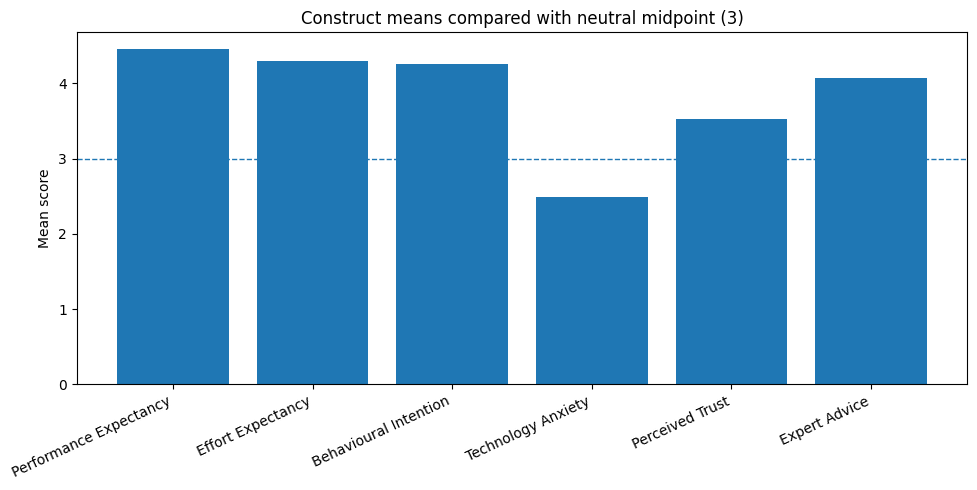

In [25]:

# Visual summary
plot_df = descriptive_df.set_index("Label").loc[
    ["Performance Expectancy", "Effort Expectancy", "Behavioural Intention", "Technology Anxiety", "Perceived Trust", "Expert Advice"]
]

plt.figure(figsize=(10, 5))
plt.bar(plot_df.index, plot_df["Mean"])
plt.axhline(3, linestyle="--", linewidth=1)
plt.ylabel("Mean score")
plt.title("Construct means compared with neutral midpoint (3)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


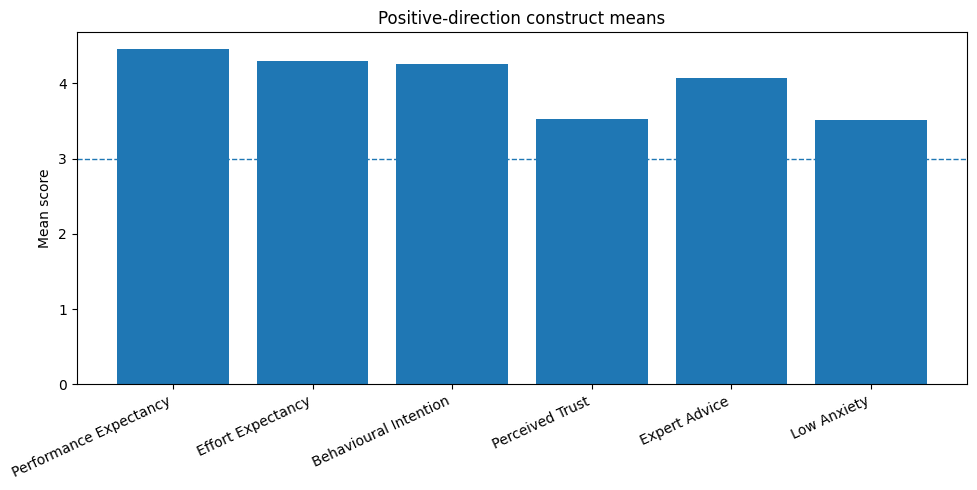

In [26]:

# Reverse anxiety for a more intuitive 'ease/confidence' visual if needed
visual_df = df_clean.copy()
visual_df["Low_Anxiety"] = 6 - visual_df["TA"]

visual_means = pd.Series({
    "Performance Expectancy": df_clean["PE"].mean(),
    "Effort Expectancy": df_clean["EE"].mean(),
    "Behavioural Intention": df_clean["BI"].mean(),
    "Perceived Trust": df_clean["PT"].mean(),
    "Expert Advice": df_clean["EA"].mean(),
    "Low Anxiety": visual_df["Low_Anxiety"].mean(),
})

plt.figure(figsize=(10, 5))
plt.bar(visual_means.index, visual_means.values)
plt.axhline(3, linestyle="--", linewidth=1)
plt.ylabel("Mean score")
plt.title("Positive-direction construct means")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Open-text responses for qualitative follow-up

These tables are useful when writing the discussion section because they help explain *why* users scored the constructs the way they did.


In [27]:

open_text_cols = [
    "Q9. First impression of the system",
    "Q15. Which feature did you find most useful?",
    "Q16. Which feature needs improvement?",
    "Q21. What risks or concerns do you see in this system? ",
    "Q32. What would you improve in this system?",
    "Q33. Are there any features not represented that you believe would add additional value to the system?",
    "Q34. Any additional comments?",
]

for col in open_text_cols:
    print("\n" + "="*120)
    print(col)
    print("="*120)
    display(df_clean[[ "role_standardized", col ]].dropna().reset_index(drop=True).head(10))



Q9. First impression of the system


,role_standardized,Q9. First impression of the system
0,Patient Relative,"My first impression of the system, is that it ..."
1,Patient Relative,This is very well thought out. This is especia...
2,Professional Caregiver,"Great innovation, the lady is very real"
3,Patient Relative,"I think everything about it is great, but perh..."
4,Patient Relative,Interaction is always beneficial with patients...
5,Patient Relative,New and good to have it
6,Allied Medical Professional,Promising
7,Professional Caregiver,Interesting dashboard to log in all patient’s ...
8,Nurse,Engaging
9,Nurse,I have a question: will the avatar use other l...



Q15. Which feature did you find most useful?


,role_standardized,Q15. Which feature did you find most useful?
0,Patient Relative,Safety and Reminder tools
1,Patient Relative,The insight tool
2,Professional Caregiver,The lady who speaks
3,Patient Relative,The avatars ability to deal with the patients ...
4,Patient Relative,The reminder system for daily routine.
5,Patient Relative,The interaction no idea
6,Allied Medical Professional,The personalization
7,Professional Caregiver,The interactive part of the system with the pa...
8,Nurse,Reminder system
9,Nurse,Burden would be also reduced for family members.



Q16. Which feature needs improvement?


...

,role_standardized,Q32. What would you improve in this system?
0,Patient Relative,I think everything works very good but the ava...
1,Patient Relative,No improvement comments
2,Professional Caregiver,nothing i could think of
3,Patient Relative,"Firstly, I think the speech quality of the ava..."
4,Patient Relative,A connection between the system and the people...
5,Allied Medical Professional,We should test on elders to see.
6,Professional Caregiver,The system is good as a prototype to start wit...
7,Nurse,Nil
8,Nurse,"This is something new, but a pilot study will ..."
9,Physician,I would pilot the system on institutionalized ...



Q33. Are there any features not represented that you believe would add additional value to the system?


,role_standardized,Q33. Are there any features not represented that you believe would add additional value to the system?
0,Patient Relative,"nope, you have every feature, you could add me..."
1,Patient Relative,All areas were covered
2,Professional Caregiver,Noi
3,Patient Relative,I believe I mentioned this in my answer above.
4,Patient Relative,The avatar's face can be designed differently ...
5,Allied Medical Professional,Can't identify any.
6,Professional Caregiver,Medication management such as automated remind...
7,Nurse,How the ADRD system gives a warning if the per...
8,Physician,The avatar's expressions are bland and may cau...
9,Patient Relative,could add cognitive games



Q34. Any additional comments?


,role_standardized,Q34. Any additional comments?
0,Patient Relative,nope :)
1,Professional Caregiver,No
2,Patient Relative,"I think this is a wonderful initiative, and I ..."
3,Patient Relative,I would like to thank you and encourage you in...
4,Patient Relative,Looking forward to see this in reality
5,Professional Caregiver,A suggestion to integrate this system with the...
6,Nurse,Good idea if applied and received properly.
7,Physician,No
8,Patient Relative,no
9,Professional Caregiver,no


## Files exported by this notebook

The notebook writes the following outputs to `/mnt/data/adrd_utaut_outputs/`:

- `cleaned_survey_data.csv`
- `reliability_summary.csv`
- `construct_descriptives.csv`
- `construct_significance_tests.csv`
- `role_difference_tests.csv`
- `role_means.csv`
- `item_summary.csv`
- `thesis_summary.csv`
